In [4]:
from spt3g import core

# Open the g3 file
g3_file = 'ccat_datacenter_mock/data_testmpi/planet_WNdata_d100/sim_PCAM280_g3_Jupiter_d100/Jupiter-0-0/frames-0000.g3'
# g3_file ='./ccat_datacenter_mock/data_testmpi/planet_WNdata_d3426/sim_PCAM280_g3_Jupiter_d3426/Jupiter-0-0/frames-0000.g3'

# Iterate over frames
for i, frame in enumerate(core.G3File(g3_file)):
    print(f"=== Frame {i} ({frame.type}) ===")
    for key in frame.keys():
        val = frame[key]
        print(f"  {key} : {type(val)}")
    print()

=== Frame 0 (Observation) ===
  scan_max_az_units : <class 'int'>
  telescope_name : <class 'str'>
  scan_max_az_astropy_units : <class 'str'>
  scan_max_az : <class 'float'>
  scan_el : <class 'float'>
  session_uid : <class 'int'>
  session_class : <class 'str'>
  site_name : <class 'str'>
  site_weather_max_pwv : <class 'float'>
  observation_name : <class 'str'>
  site_class : <class 'str'>
  session_name : <class 'str'>
  scan_el_astropy_units : <class 'str'>
  site_alt_m : <class 'float'>
  site_lon_deg : <class 'float'>
  scan_max_el : <class 'float'>
  scan_min_az_units : <class 'int'>
  site_weather_time : <class 'spt3g._libcore.G3Time'>
  site_uid : <class 'int'>
  scan_max_el_astropy_units : <class 'str'>
  scan_min_az_astropy_units : <class 'str'>
  scan_min_el_units : <class 'int'>
  scan_max_el_units : <class 'int'>
  telescope_class : <class 'str'>
  telescope_uid : <class 'int'>
  site_lat_deg : <class 'float'>
  site_weather_uid : <class 'int'>
  scan_el_units : <class

In [6]:
# Read everything into a list of frames
frames = list(core.G3File(g3_file))

print(f"Loaded {len(frames)} frames")
print([f"{i}: {fr.type.name}" for i, fr in enumerate(frames)])

# Inspect a specific frame
frame_idx = 4
print(f"{frame_idx}: {frames[frame_idx].type}\n\t{list(frames[frame_idx].keys())}")

Loaded 30 frames
['0: Observation', '1: Calibration', '2: PipelineInfo', '3: Scan', '4: Scan', '5: Scan', '6: Scan', '7: Scan', '8: Scan', '9: Scan', '10: Scan', '11: Scan', '12: Scan', '13: Scan', '14: Scan', '15: Scan', '16: Scan', '17: Scan', '18: Scan', '19: Scan', '20: Scan', '21: Scan', '22: Scan', '23: Scan', '24: Scan', '25: Scan', '26: Scan', '27: Scan', '28: Scan', '29: Scan']
4: Scan
	['compress_signal_w2_p1375_PC_f280_B_offset', 'compress_signal_w2_p1128_PC_f280_B_offset', 'compress_signal_w2_p1375_PC_f280_A_units', 'compress_signal_w2_p1515_PC_f280_A_gain', 'compress_signal_w2_p1692_PC_f280_B_units', 'compress_signal_w2_p1375_PC_f280_A_offset', 'compress_signal_w2_p1340_PC_f280_B_offset', 'compress_signal_w2_p0422_PC_f280_B_offset', 'compress_signal_w2_p0034_PC_f280_B_offset', 'compress_signal_w2_p1550_PC_f280_A_gain', 'compress_signal_w2_p1340_PC_f280_B_gain', 'compress_signal_w2_p0986_PC_f280_A_gain', 'compress_signal_w2_p1340_PC_f280_A_units', 'compress_signal_w2_p1305_

In [6]:
import io, h5py

for i, fr in enumerate(frames):
    if "focalplane" in fr:
        raw = bytes(fr["focalplane"])       # byte string
        with h5py.File(io.BytesIO(raw), "r") as f:
            print(f"Frame {i} focalplane HDF5 groups:", list(f.keys()))
            # Explore inside:
            for k in f.keys():
                print(f"  {k} -> {list(f[k].keys()) if hasattr(f[k], 'keys') else type(f[k])}")

Frame 1 focalplane HDF5 groups: ['focalplane', 'focalplane.__table_column_meta__']
  focalplane -> <class 'h5py._hl.dataset.Dataset'>
  focalplane.__table_column_meta__ -> <class 'h5py._hl.dataset.Dataset'>


In [7]:
raw = bytes(frames[1]["focalplane"])  # use your frame index

with h5py.File(io.BytesIO(raw), "r") as f:
    dset = f["focalplane"]                     # compound (table) dataset
    meta = f["focalplane.__table_column_meta__"]
    print("nrows:", dset.shape[0])
    print("columns:", list(dset.dtype.names))
    print("dtypes:", {k: dset.dtype.fields[k][0] for k in dset.dtype.names})
        
    # # Turn into a list of Python strings
    # meta_strings = [s.decode("utf-8").strip() for s in meta[...]]
    # print("n entries:", len(meta_strings))
    # print("first few:", meta_strings[:10])

nrows: 10
columns: ['name', 'quat', 'xy_offset', 'wafer_slot', 'band', 'pixel', 'pol', 'psi_pol', 'gamma', 'fwhm', 'psd_fmin', 'psd_fknee', 'psd_alpha', 'psd_net', 'bandcenter', 'bandwidth', 'index', 'uid', 'pol_angle', 'pol_efficiency', 'pol_leakage']
dtypes: {'name': dtype('S18'), 'quat': dtype(('<f8', (4,))), 'xy_offset': dtype(('<f8', (2,))), 'wafer_slot': dtype('S2'), 'band': dtype('S7'), 'pixel': dtype('S4'), 'pol': dtype('S1'), 'psi_pol': dtype('<f8'), 'gamma': dtype('<f8'), 'fwhm': dtype('<f8'), 'psd_fmin': dtype('<f8'), 'psd_fknee': dtype('<f8'), 'psd_alpha': dtype('<f8'), 'psd_net': dtype('<f8'), 'bandcenter': dtype('<f8'), 'bandwidth': dtype('<f8'), 'index': dtype('int64'), 'uid': dtype('int64'), 'pol_angle': dtype('<f8'), 'pol_efficiency': dtype('<f8'), 'pol_leakage': dtype('<f8')}


In [ ]:
import io, h5py
raw = bytes(frames[1]["focalplane"])  # use your frame index

with h5py.File(io.BytesIO(raw), "r") as f:
    dset = f["focalplane"]                     # compound (table) dataset
    meta = f["focalplane.__table_column_meta__"]
    print("nrows:", dset.shape[0])
    print("columns:", list(dset.dtype.names))
    print("dtypes:", {k: dset.dtype.fields[k][0] for k in dset.dtype.names})
        
    # # Turn into a list of Python strings
    # meta_strings = [s.decode("utf-8").strip() for s in meta[...]]
    # print("n entries:", len(meta_strings))
    # print("first few:", meta_strings[:10])

nrows: 10
columns: ['name', 'quat', 'pol_leakage', 'psi_pol', 'gamma', 'fwhm', 'psd_fmin', 'psd_fknee', 'psd_alpha', 'psd_net', 'bandcenter', 'bandwidth', 'wafer_slot', 'ID', 'pixel', 'band', 'pol', 'index', 'uid', 'pol_angle', 'pol_efficiency']
dtypes: {'name': dtype('S18'), 'quat': dtype(('<f8', (4,))), 'pol_leakage': dtype('<f8'), 'psi_pol': dtype('<f8'), 'gamma': dtype('<f8'), 'fwhm': dtype('<f8'), 'psd_fmin': dtype('<f8'), 'psd_fknee': dtype('<f8'), 'psd_alpha': dtype('<f8'), 'psd_net': dtype('<f8'), 'bandcenter': dtype('<f8'), 'bandwidth': dtype('<f8'), 'wafer_slot': dtype('S3'), 'ID': dtype('int64'), 'pixel': dtype('S3'), 'band': dtype('S7'), 'pol': dtype('S1'), 'index': dtype('int64'), 'uid': dtype('int64'), 'pol_angle': dtype('<f8'), 'pol_efficiency': dtype('<f8')}


In [8]:
raw = bytes(frames[1]["focalplane"])  # use your frame index

with h5py.File(io.BytesIO(raw), "r") as f:
    dset = f["focalplane"]  
    arr = dset[:5]     # first 5 rows
for i, row in enumerate(arr):
    print(i, {k: row[k] for k in dset.dtype.names})

0 {'name': np.bytes_(b'w2_p0000_PC_f280_A'), 'quat': array([-0.00236614, -0.00469671, -0.50000271,  0.86600787]), 'xy_offset': array([-0.33052402,  0.50392141]), 'wafer_slot': np.bytes_(b'w2'), 'band': np.bytes_(b'PC_f280'), 'pixel': np.bytes_(b'0000'), 'pol': np.bytes_(b'A'), 'psi_pol': np.float64(0.0), 'gamma': np.float64(-4.188797643359865), 'fwhm': np.float64(0.78), 'psd_fmin': np.float64(0.001), 'psd_fknee': np.float64(1.0), 'psd_alpha': np.float64(1.0), 'psd_net': np.float64(0.00118396), 'bandcenter': np.float64(280.0), 'bandwidth': np.float64(60.0), 'index': np.int64(3426), 'uid': np.int64(3274576627), 'pol_angle': np.float64(2.0943728756412945), 'pol_efficiency': np.float64(1.0), 'pol_leakage': np.float64(0.0)}
1 {'name': np.bytes_(b'w2_p0000_PC_f280_B'), 'quat': array([-0.00499419, -0.00164796,  0.25880473,  0.96591534]), 'xy_offset': array([-0.33052402,  0.50392141]), 'wafer_slot': np.bytes_(b'w2'), 'band': np.bytes_(b'PC_f280'), 'pixel': np.bytes_(b'0000'), 'pol': np.bytes_(

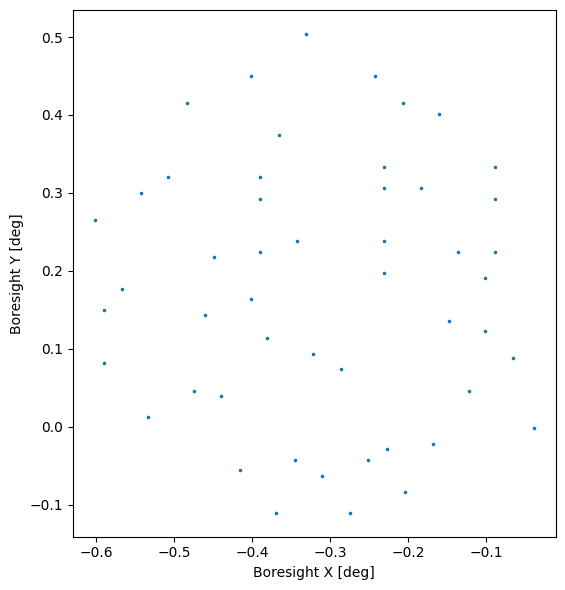

In [13]:
import io, h5py
import numpy as np
import matplotlib.pyplot as plt

# choose the calibration frame index that has "focalplane"
cal_idx = 1  # change if needed

raw = bytes(frames[cal_idx]["focalplane"])
with h5py.File(io.BytesIO(raw), "r") as f:
    dset = f["focalplane"]
    xy = dset["xy_offset"][...]        # shape (N, 2), in degrees
    x_off = xy[:, 0]
    y_off = xy[:, 1]

plt.figure(figsize=(6,6))
plt.scatter(x_off, y_off, s=2)
plt.xlabel("Boresight X [deg]")
plt.ylabel("Boresight Y [deg]")
plt.gca().set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()

In [6]:
from spt3g import core
import numpy as np

fr = frames[15]  # your Scan frame

# times (float seconds since UNIX epoch, for example)
times = np.array([float(t) for t in fr["times"]])

# boresight (RA/Dec deg already provided)
radec = np.asarray(fr["shared_radec_deg"]).reshape(-1, 2)  # shape (nsamp, 2)

# detector timestreams
tsmap = fr["signal"]  # G3TimestreamMap: iterate det names
det_list = list(tsmap.keys())
y = {det: np.asarray(tsmap[det], dtype=float) for det in det_list}

# flags per detector (map det -> vector[int])
flagmap = fr["flags"]
flags = {det: np.asarray(flagmap[det], dtype=int) for det in flagmap.keys()}

# (Optional) de-compress back to original floating values if you stored as ints:
def decompress(fr, det, vec):
    gk = f"compress_signal_{det}_gain"
    ok = f"compress_signal_{det}_offset"
    if gk in fr and ok in fr:
        return float(fr[gk]) * vec + float(fr[ok])
    return vec

y_float = {det: decompress(fr, det, y[det]) for det in det_list}


In [7]:
print("Scan nsamp:", len(times))
print("N det:", len(det_list), "example det:", det_list[:3])
print("signal_dtype:", fr.get("signal_dtype", "NA"))
print("flags_dtype:", fr.get("flags_dtype", "NA"))


Scan nsamp: 7668
N det: 100 example det: ['w2_p0000_PC_f280_A', 'w2_p0000_PC_f280_B', 'w2_p0034_PC_f280_A']
signal_dtype: d
flags_dtype: B


In [14]:
tsmap.keys()[:5]

['w2_p0000_PC_f280_A',
 'w2_p0000_PC_f280_B',
 'w2_p0034_PC_f280_A',
 'w2_p0034_PC_f280_B',
 'w2_p0069_PC_f280_A']

In [15]:
import numpy as np

det1, det2 = list(tsmap.keys())[:2]   # pick two detectors

sig1 = np.asarray(tsmap[det1], dtype=float)
sig2 = np.asarray(tsmap[det2], dtype=float)

times = np.array([float(t) for t in fr["times"]])  # G3VectorTime → float

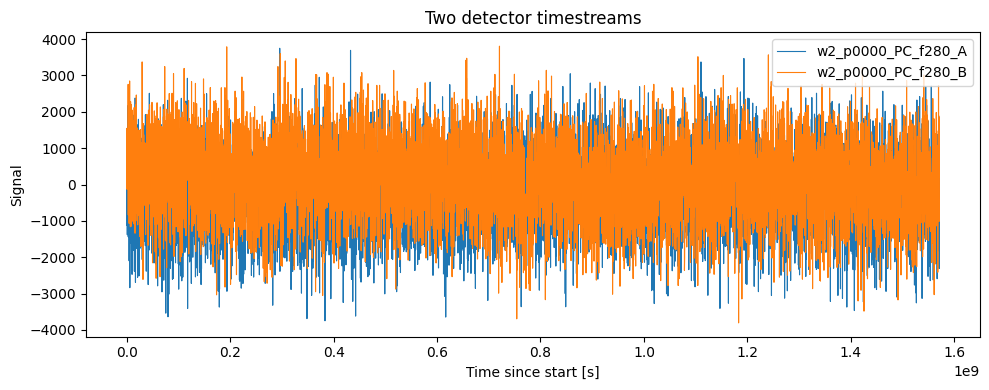

In [16]:
import matplotlib.pyplot as plt

t0 = times[0]
plt.figure(figsize=(10,4))
plt.plot(times - t0, sig1, label=det1, lw=0.8)
plt.plot(times - t0, sig2, label=det2, lw=0.8)
plt.xlabel("Time since start [s]")
plt.ylabel("Signal")
plt.title("Two detector timestreams")
plt.legend()
plt.tight_layout()
plt.show()


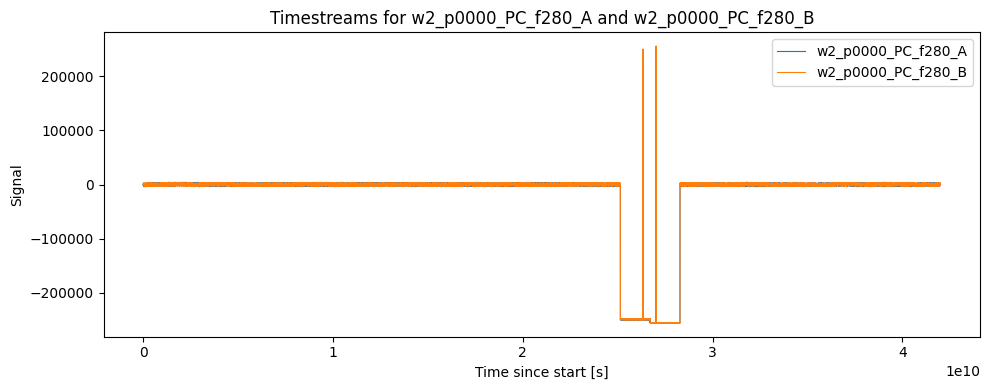

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from spt3g import core

det1, det2 = None, None
all_t1, all_y1, all_t2, all_y2 = [], [], [], []

for fr in frames:
    if fr.type == core.G3FrameType.Scan:
        tsmap = fr["signal"]
        t = np.array([float(t) for t in fr["times"]])

        # pick detectors if not set yet
        if det1 is None or det2 is None:
            dets = list(tsmap.keys())
            det1, det2 = dets[0], dets[1]

        # extract signals
        y1 = np.asarray(tsmap[det1], dtype=float)
        y2 = np.asarray(tsmap[det2], dtype=float)

        all_t1.append(t); all_y1.append(y1)
        all_t2.append(t); all_y2.append(y2)

# concatenate
times1 = np.concatenate(all_t1)
sig1   = np.concatenate(all_y1)
times2 = np.concatenate(all_t2)
sig2   = np.concatenate(all_y2)

# plot
t0 = min(times1[0], times2[0])
plt.figure(figsize=(10,4))
plt.plot(times1 - t0, sig1, label=det1, lw=0.8)
plt.plot(times2 - t0, sig2, label=det2, lw=0.8)
plt.xlabel("Time since start [s]")
plt.ylabel("Signal")
plt.title(f"Timestreams for {det1} and {det2}")
plt.legend()
plt.tight_layout()
plt.show()


In [18]:
import numpy as np
from spt3g import core

def decompress_signals_for_frame(fr, dets=None):
    """Return times (np.float64) and a dict det-> np.float64 (decompressed)."""
    assert fr.type == core.G3FrameType.Scan
    # times
    t = np.array([float(x) for x in fr["times"]], dtype=float)
    # raw signals map
    tsmap = fr["signal"]  # G3TimestreamMap
    all_dets = list(tsmap.keys())
    if dets is None:
        dets = all_dets
    out = {}
    for d in dets:
        y_stored = np.asarray(tsmap[d], dtype=float)
        gk = f"compress_signal_{d}_gain"
        ok = f"compress_signal_{d}_offset"
        if gk in fr and ok in fr:
            gain   = float(fr[gk])
            offset = float(fr[ok])
            y = gain * y_stored + offset
        else:
            # no compression metadata → assume already physical
            y = y_stored
        out[d] = y
    return t, out


In [19]:
from spt3g import core

det1, det2 = None, None
T, Y1, Y2 = [], [], []

for fr in frames:
    if fr.type == core.G3FrameType.Scan:
        # pick detectors once
        if det1 is None or det2 is None:
            ds = list(fr["signal"].keys())
            det1, det2 = ds[0], ds[1]
        t, y = decompress_signals_for_frame(fr, dets=[det1, det2])
        T.append(t); Y1.append(y[det1]); Y2.append(y[det2])

t_all = np.concatenate(T)
y1_all = np.concatenate(Y1)
y2_all = np.concatenate(Y2)


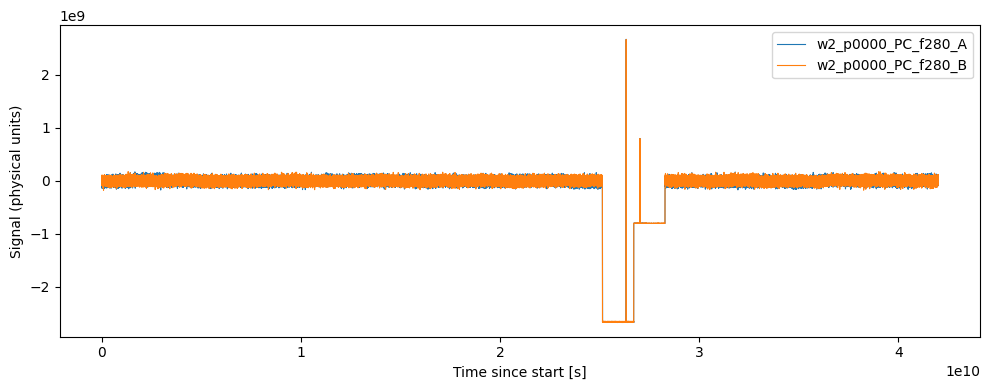

In [20]:
import matplotlib.pyplot as plt
t0 = t_all[0]
plt.figure(figsize=(10,4))
plt.plot(t_all - t0, y1_all, label=det1, lw=0.8)
plt.plot(t_all - t0, y2_all, label=det2, lw=0.8)
plt.xlabel("Time since start [s]")
plt.ylabel("Signal (physical units)")
plt.legend(); plt.tight_layout(); plt.show()


In [21]:
for i, fr in enumerate(frames):
    if fr.type.name == "Scan":
        gk = f"compress_signal_{det1}_gain"
        ok = f"compress_signal_{det1}_offset"
        if gk in fr:
            print(i, fr[gk], fr[ok])


3 39241.83440348025 0.005672944127074364
4 38771.20399745732 -0.02066564100609257
5 38386.929183913046 0.0006614995053533385
6 38742.380696508735 0.005108906839036927
7 39223.58494503918 0.002744694272977591
8 38783.82927534117 0.011409397449998124
9 38691.06824632511 0.004506172646471532
10 39071.90135745067 -0.006801466658253347
11 39811.90209199335 -0.007430125114079492
12 39177.28244715799 -0.0003729850126572565
13 38930.757163019705 0.008406451588901645
14 38705.92983190408 0.004576203336833437
15 38786.755578687094 0.007128176891562525
16 39025.10538304219 -0.004140816088645416
17 39044.46413903385 0.000514949731328665
18 39211.324173856454 0.014199190548708232
19 10680.434866236279 23.336887668871423
20 3134.3722176747233 81.5140016310117
21 39159.203739656325 0.01110118341115017
22 39206.01038377727 0.0025115813921267813
23 37957.6436678747 0.013837128907397155
24 38995.50225258561 8.080442728086029e-05
25 39494.33031231513 0.005815274375840743
26 38641.43338109616 -0.005220599

Processing frame 3 ...
Processing frame 4 ...


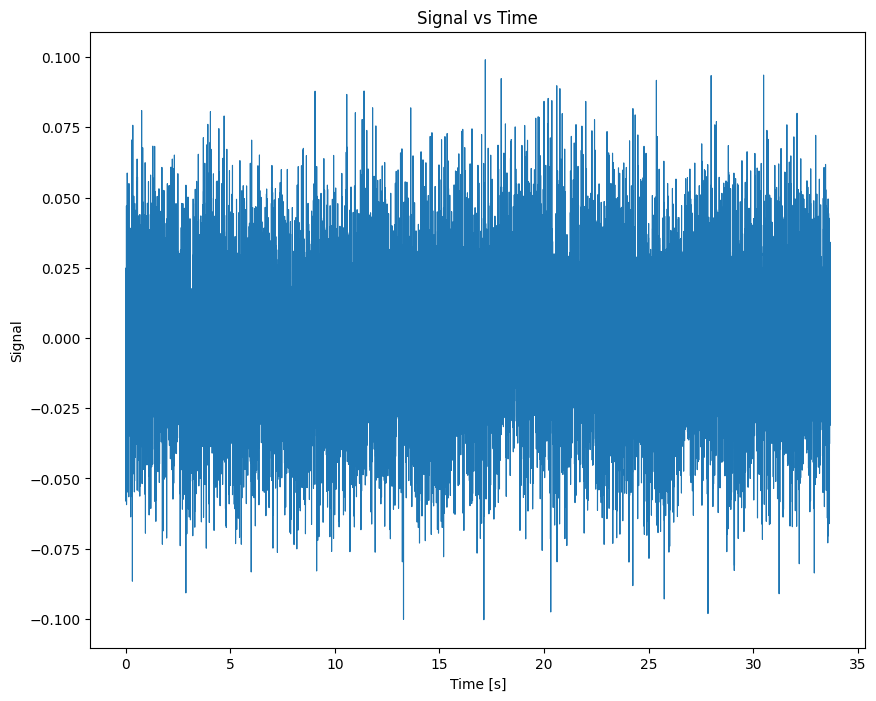

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from spt3g import core

#Put g3 file here
g3_file ='./ccat_datacenter_mock/data_testmpi/planet_WNdata_d3426/sim_PCAM280_g3_Jupiter_d3426/Jupiter-1-0/frames-0002.g3'
# g3_file ='./ccat_datacenter_mock/data_testmpi/planet_WNdata_d100/sim_PCAM280_g3_Jupiter_d100/Jupiter-0-0/frames-0000.g3'
# Toggle to process 1 scan frame or all frames
plot_single_frame = False
frame_id = 20

fs = 488.0  # Hz
det_name = None
signal_det = []
y_all, ra_all, dec_all = [], [], []
frames = list(core.G3File(g3_file))

for fr_idx, fr in enumerate(frames):
    if (fr.type == core.G3FrameType.Scan and 
            (fr_idx == frame_id if plot_single_frame else True)):
        print(f'Processing frame {fr_idx} ...')
        raw_signal = fr["signal"]
        if det_name is None:
            det_name = next(iter(raw_signal.keys()))

        # raw samples
        y_raw = np.asarray(raw_signal[det_name], dtype=float)

        # per-frame reconstruction
        gain_key = f"compress_signal_{det_name}_gain"
        offset_key = f"compress_signal_{det_name}_offset"
        if gain_key in fr and offset_key in fr:
            gain = float(fr[gain_key])
            offset = float(fr[offset_key])
            reconstructed_y = y_raw/gain + offset
        
        # per frame
        radec = np.asarray(fr["shared_radec_deg"], float).reshape(-1, 2)
        n = min(len(reconstructed_y), radec.shape[0])
        if n:
            signal_det.append(reconstructed_y[:n])
            ra_all.append(radec[:n, 0])
            dec_all.append(radec[:n, 1])

signal, ra_deg, dec_deg = map(np.concatenate, (signal_det, ra_all, dec_all))
t = np.arange(len(signal)) / fs  # seconds since start

title_suffix = (
    f"for frame {frame_id}" if plot_single_frame else "for all Scan frames"
)

fig, ax1 = plt.subplots(1, 1, figsize=(10, 8))

# --- Signal vs Time ---
ax1.plot(t, signal, lw=0.8)
ax1.set_xlabel("Time [s]")
ax1.set_ylabel("Signal")
ax1.set_title("Signal vs Time")

plt.show()

Processing frame 3 ...
Processing frame 4 ...


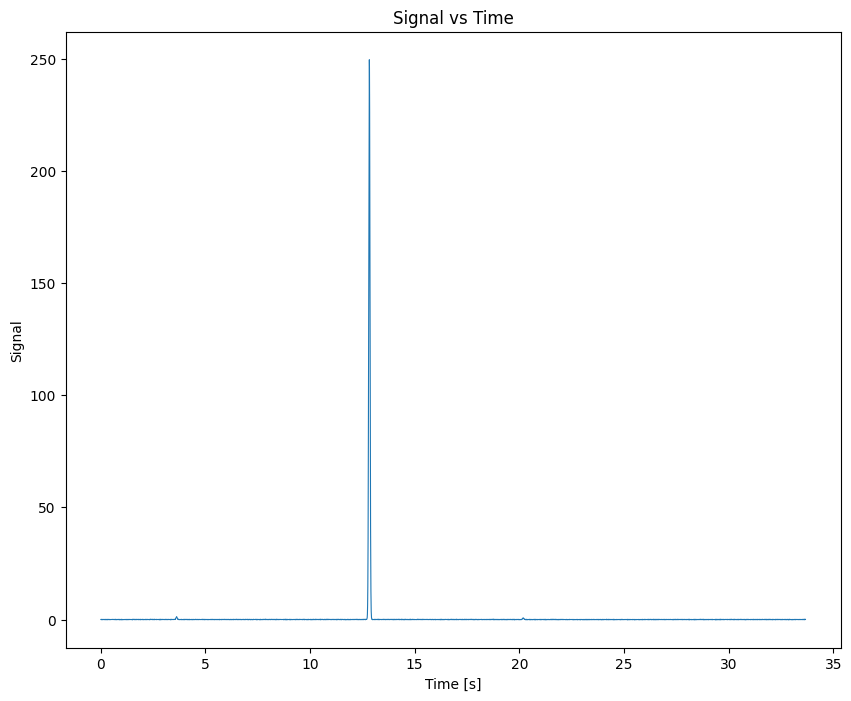

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from spt3g import core

#Put g3 file here
g3_file ='./ccat_datacenter_mock/data_testmpi/planet_WNdata_d3426/sim_PCAM280_g3_Jupiter_d3426/Jupiter-1-0/frames-0008.g3'
fs = 488.0  # Hz
det_name = None
signal_det = []
y_all, ra_all, dec_all = [], [], []
frames = list(core.G3File(g3_file))

for fr_idx, fr in enumerate(frames):
    if (fr.type == core.G3FrameType.Scan):
        print(f'Processing frame {fr_idx} ...')
        raw_signal = fr["signal"]
        if det_name is None:
            det_name = next(iter(raw_signal.keys()))

        # raw samples
        y_raw = np.asarray(raw_signal[det_name], dtype=float)

        # per-frame reconstruction
        gain_key = f"compress_signal_{det_name}_gain"
        offset_key = f"compress_signal_{det_name}_offset"
        if gain_key in fr and offset_key in fr:
            gain = float(fr[gain_key])
            offset = float(fr[offset_key])
            reconstructed_y = y_raw/gain + offset
        
        # per frame
        radec = np.asarray(fr["shared_radec_deg"], float).reshape(-1, 2)
        n = min(len(reconstructed_y), radec.shape[0])
        if n:
            signal_det.append(reconstructed_y[:n])
            ra_all.append(radec[:n, 0])
            dec_all.append(radec[:n, 1])

signal, ra_deg, dec_deg = map(np.concatenate, (signal_det, ra_all, dec_all))
t = np.arange(len(signal)) / fs  # seconds since start

fig, ax1 = plt.subplots(1, 1, figsize=(10, 8))

# --- Signal vs Time ---
ax1.plot(t, signal, lw=0.8)
ax1.set_xlabel("Time [s]")
ax1.set_ylabel("Signal")
ax1.set_title("Signal vs Time")

plt.show()